In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_excel('EastWestAirlines.xlsx',sheet_name=1)

In [3]:
df.shape

(3999, 12)

In [4]:
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [6]:
## 1.	Preprocess the dataset to handle missing values, remove outliers, and scale the features if necessary.

In [7]:
df.isnull().sum()

,0
ID#,0
Balance,0
Qual_miles,0
cc1_miles,0
cc2_miles,0
cc3_miles,0
Bonus_miles,0
Bonus_trans,0
Flight_miles_12mo,0
Flight_trans_12,0


In [8]:
df.duplicated().sum()

np.int64(0)

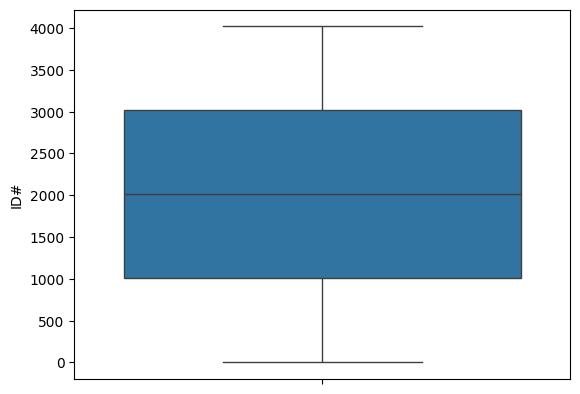

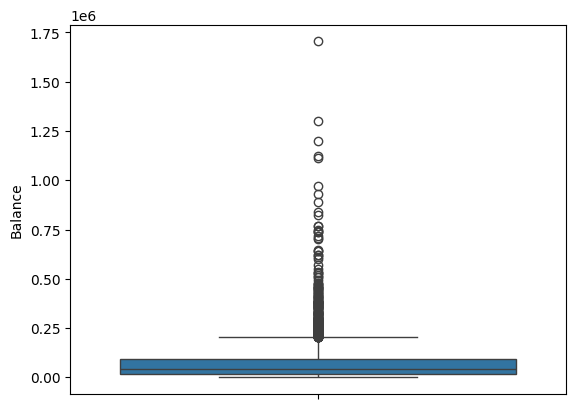

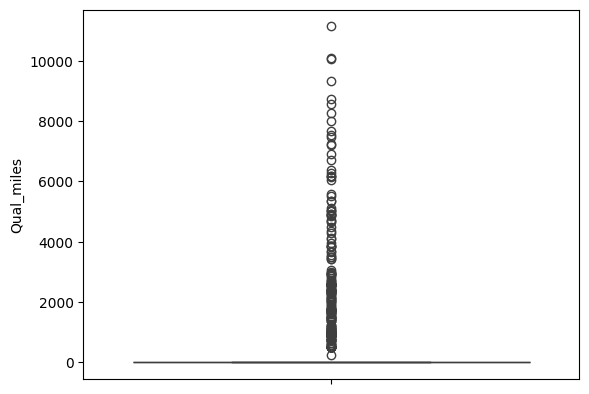

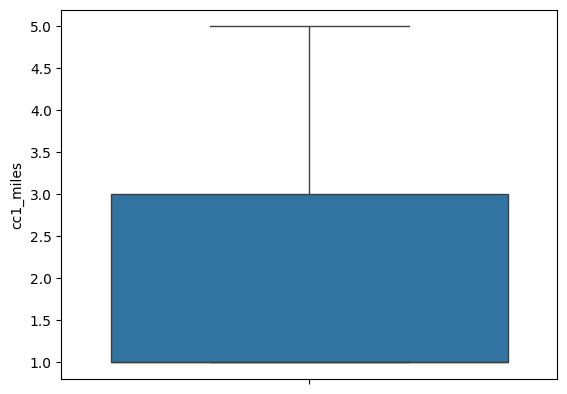

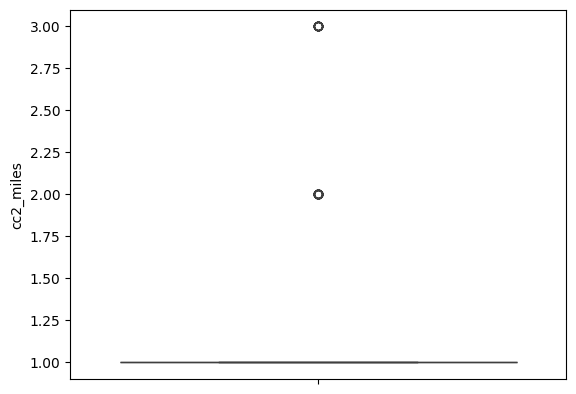

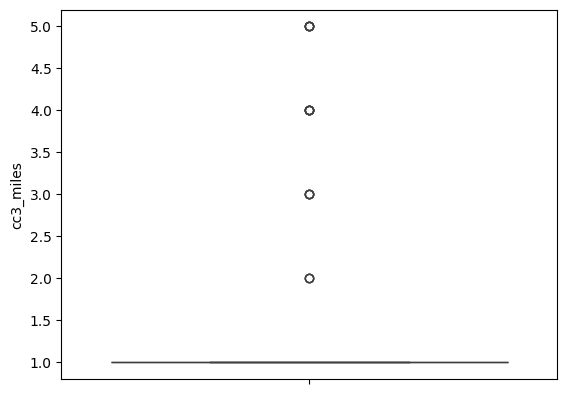

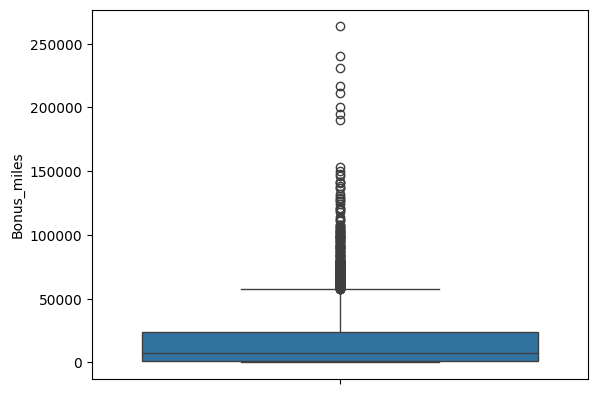

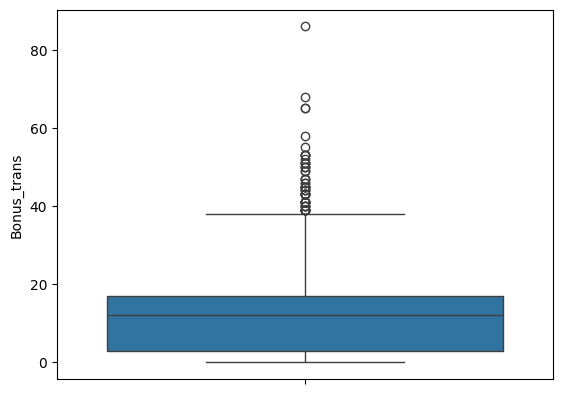

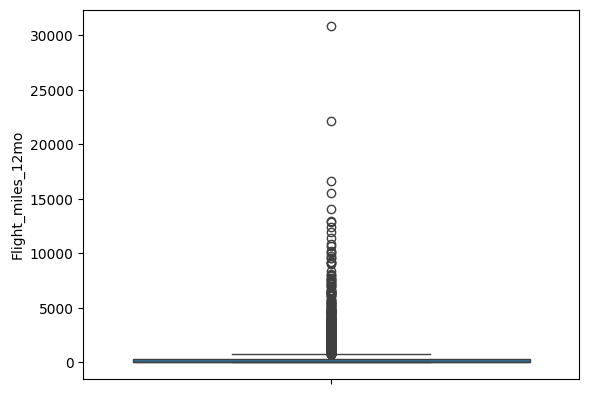

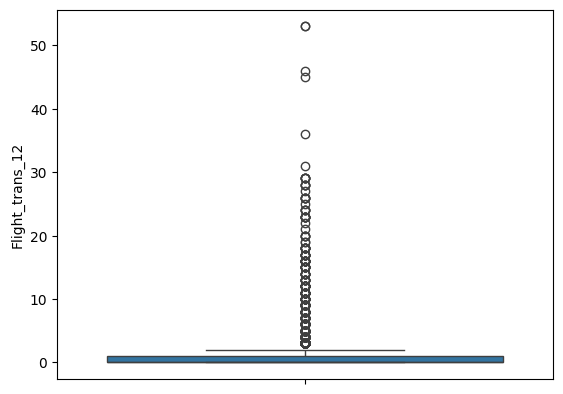

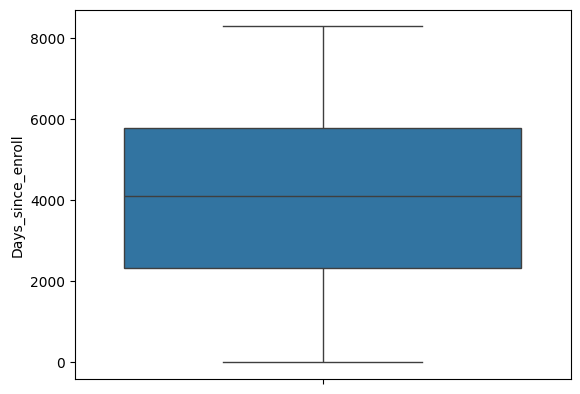

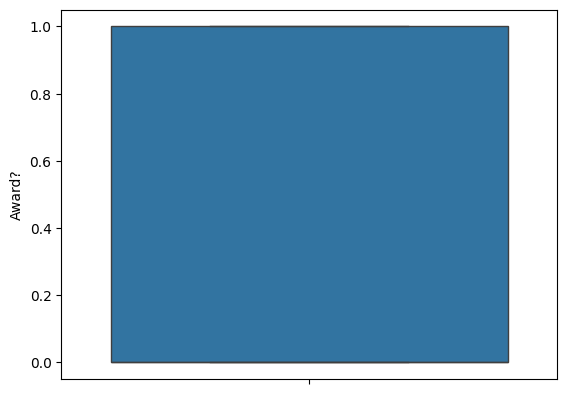

In [9]:
for col in df.columns:
    sns.boxplot(df[col])
    plt.show()

In [10]:
## Outlier capping
def outlier_capping(df,columns):
    Q1= df[columns].quantile(0.25)
    Q3 = df[columns].quantile(0.75)
    IQR = Q3 -Q1
    lower_extreme = Q1 - 1.5*IQR
    upper_extreme = Q3 + 1.5*IQR
    df[columns] = df[columns].apply(lambda x:lower_extreme if x<lower_extreme else
                                    upper_extreme if x> upper_extreme else x)
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

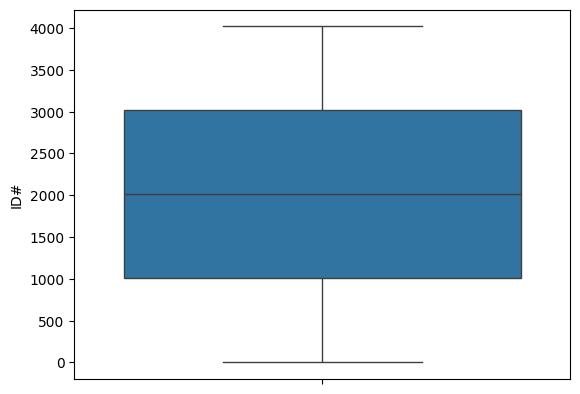

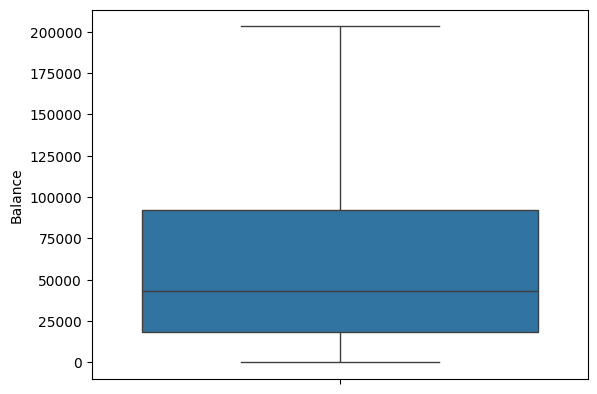

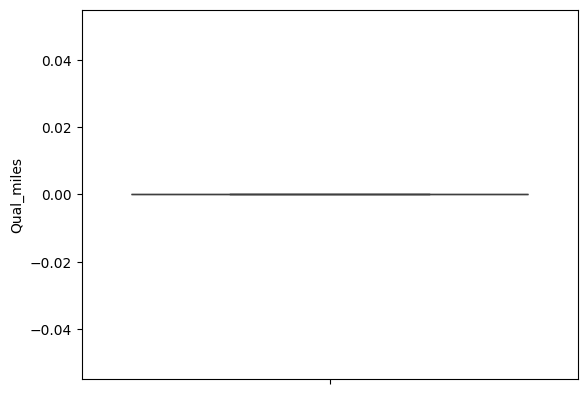

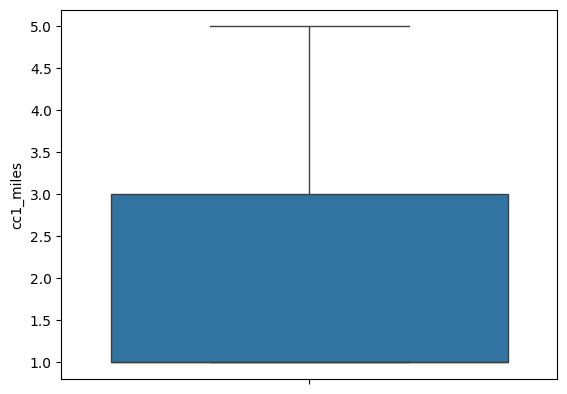

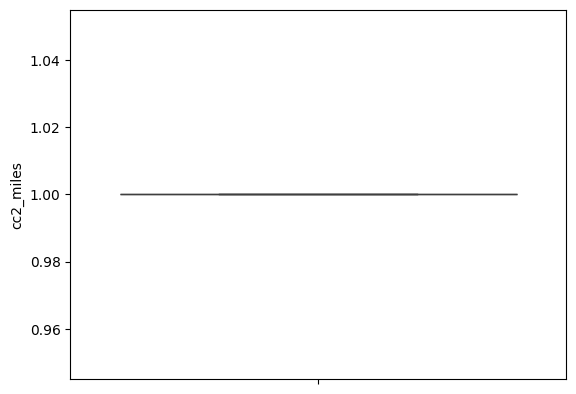

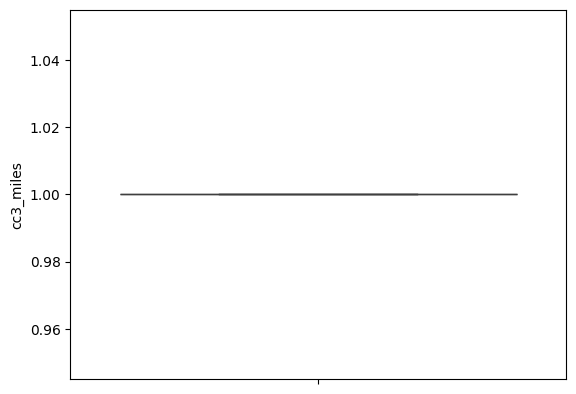

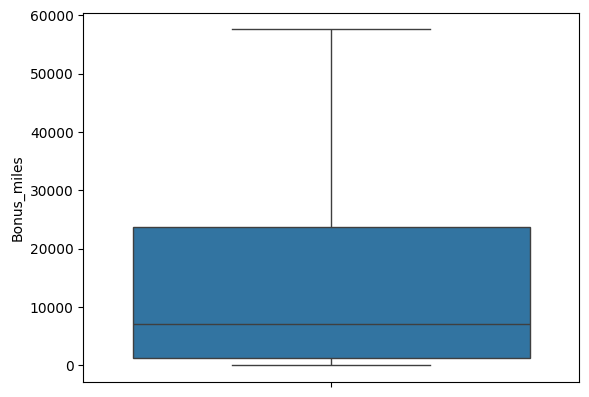

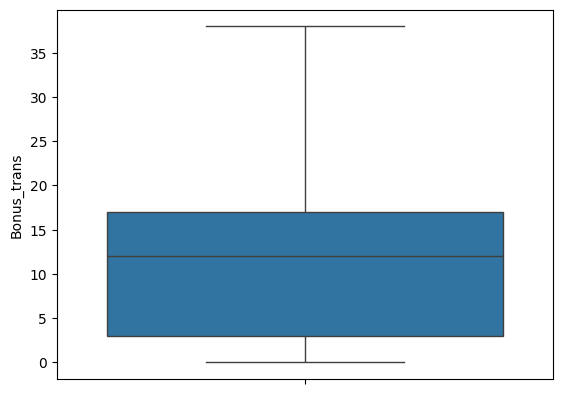

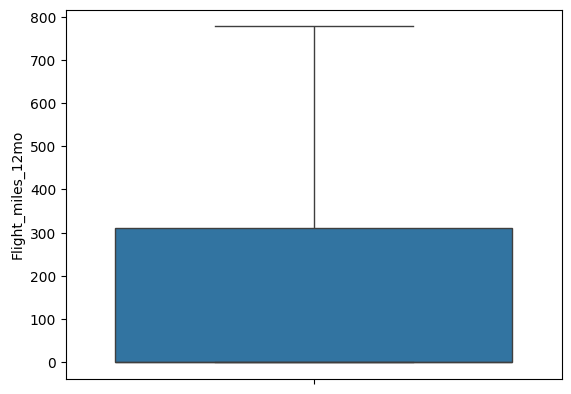

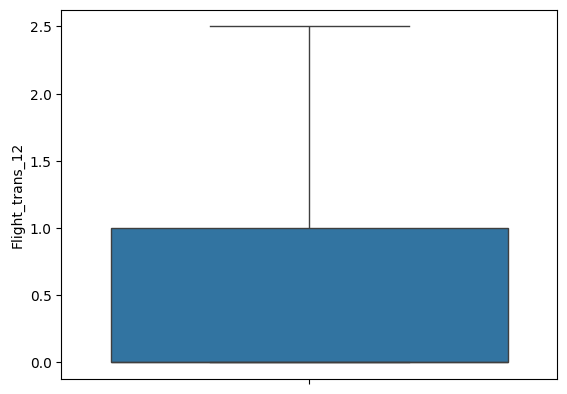

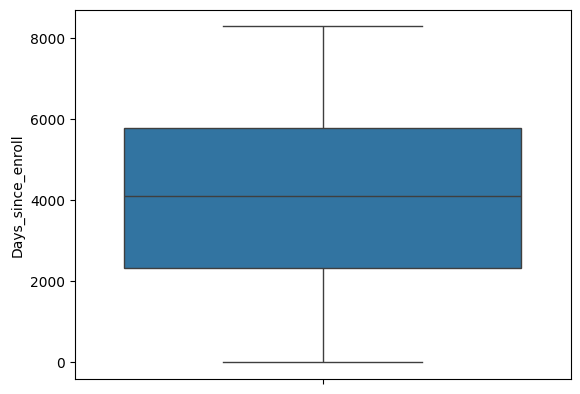

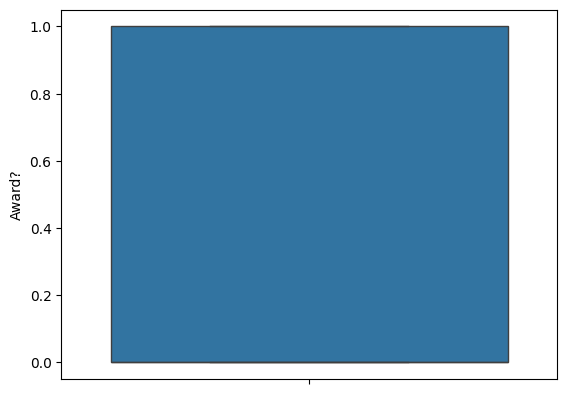

In [11]:
for col in df.columns:
    sns.boxplot(df[col])
    plt.show()

In [12]:
df1 = df.drop(columns=['ID#','Award?'])
df1.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
0,28143.0,0.0,1,1.0,1.0,174.0,1.0,0.0,0.0,7000
1,19244.0,0.0,1,1.0,1.0,215.0,2.0,0.0,0.0,6968
2,41354.0,0.0,1,1.0,1.0,4123.0,4.0,0.0,0.0,7034
3,14776.0,0.0,1,1.0,1.0,500.0,1.0,0.0,0.0,6952
4,97752.0,0.0,4,1.0,1.0,43300.0,26.0,777.5,2.5,6935


In [13]:
## Scaling
std_sca = StandardScaler()
df1 = pd.DataFrame(std_sca.fit_transform(df1),columns=df1.columns)

In [14]:
df1.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
0,-0.607258,0.0,-0.769578,0.0,0.0,-0.843091,-1.148854,-0.604313,-0.626143,1.395454
1,-0.758947,0.0,-0.769578,0.0,0.0,-0.840822,-1.039133,-0.604313,-0.626143,1.379957
2,-0.382070,0.0,-0.769578,0.0,0.0,-0.624581,-0.819689,-0.604313,-0.626143,1.411920
3,-0.835106,0.0,-0.769578,0.0,0.0,-0.825052,-1.148854,-0.604313,-0.626143,1.372208
4,0.579265,0.0,1.409471,0.0,0.0,1.543191,1.594189,2.034489,2.020176,1.363975


In [15]:
## Perform exploratory data analysis (EDA) to gain insights into the distribution of data and identify potential clusters.

In [16]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3999.000000,3999.0,3999.000000,3999.0,3999.0,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,63768.635784,0.0,2.059515,1.0,1.0,15410.730683,11.470618,178.055639,0.591523,4118.55939,0.370343
std,1160.764358,58673.700736,0.0,1.376919,0.0,0.0,18074.733482,9.115104,294.678028,0.944826,2065.13454,0.482957
min,1.000000,0.000000,0.0,1.000000,1.0,1.0,0.000000,0.000000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,18527.500000,0.0,1.000000,1.0,1.0,1250.000000,3.000000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,43097.000000,0.0,1.000000,1.0,1.0,7171.000000,12.000000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,92404.000000,0.0,3.000000,1.0,1.0,23800.500000,17.000000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,203218.750000,0.0,5.000000,1.0,1.0,57626.250000,38.000000,777.500000,2.500000,8296.00000,1.000000


From the above table we can see that
- ID - Mean is less than median , that indicates weak left skeweness, presence of outliers.
- Balance - The mean is greater than median, that means the data distribution is right skewed, presence of outlier
- Qual_miles - The mean and median is 0, that means data distribution is centered.
- cc1_miles - Mean is greater than median , that indicates right skeweness, presence of outliers.
- cc2_miles - The mean and median is 1, that means data distribution is symmetric.
- cc3_miles - The mean and median is 1, that means data distribution is symmetric.
- Bonus_miles - Mean is greater than median , that indicates right skeweness, presence of outliers.
- Bonus_trans - The mean is less than median, that means the data distribution is left skewed, presence of outlier.
- Flight_miles_12mo - The mean is much greater than median, that means the data distribution is strong right skewed, presence of outlier.
- Flight_trans_12	- Mean is greater than median , that indicates weak right skeweness, presence of outliers.
- Days_since_enroll - Mean is greater than median , that indicates right skeweness, presence of outliers.
- Award - Mean is greater than median , that indicates weak right skeweness, presence of outliers.

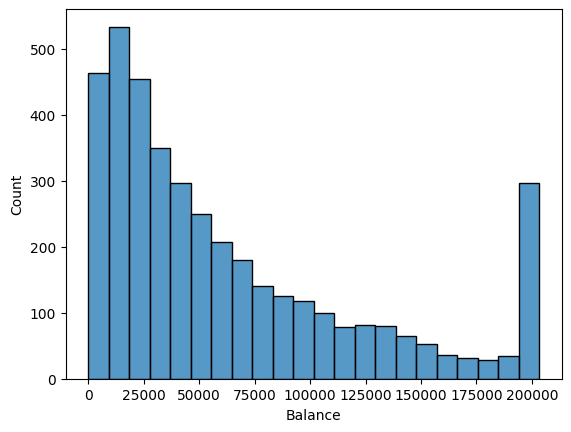

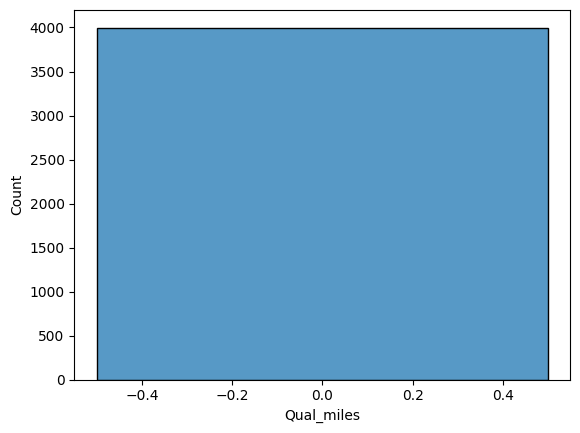

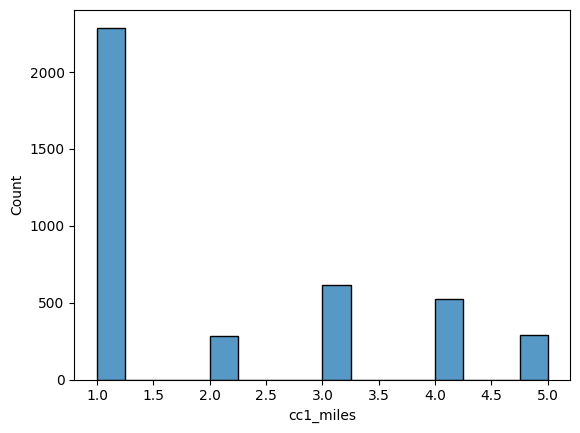

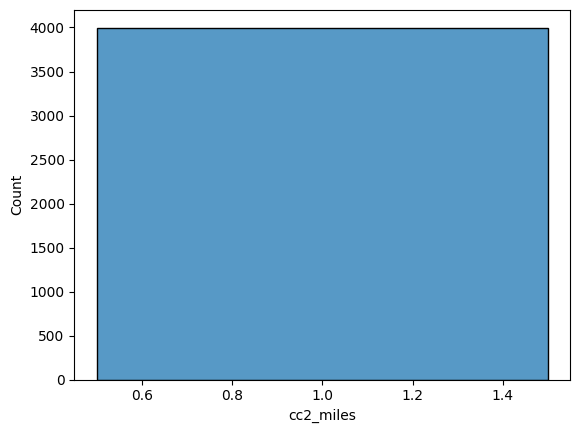

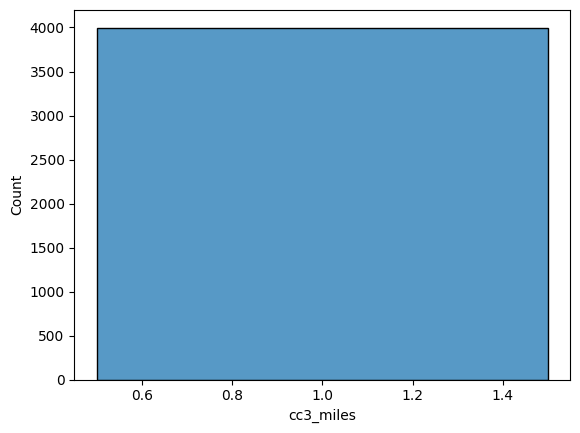

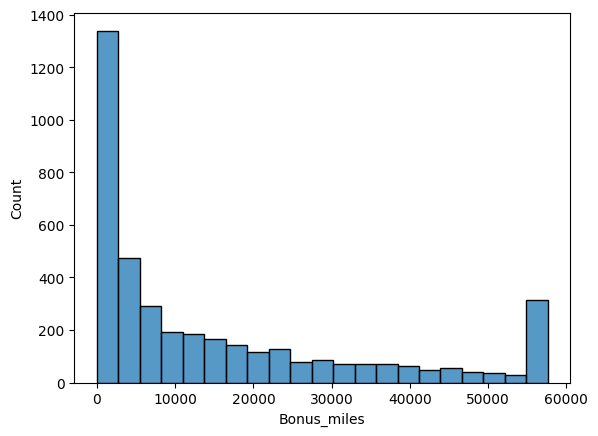

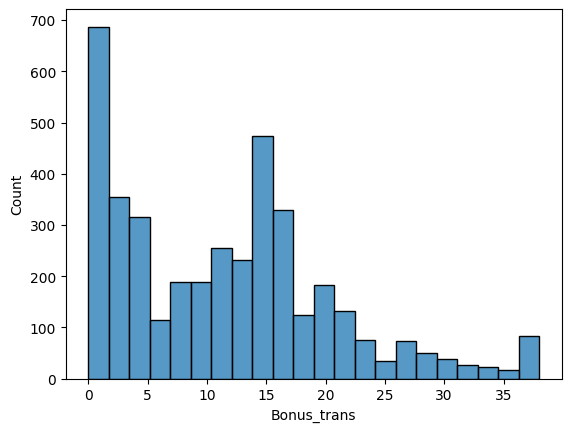

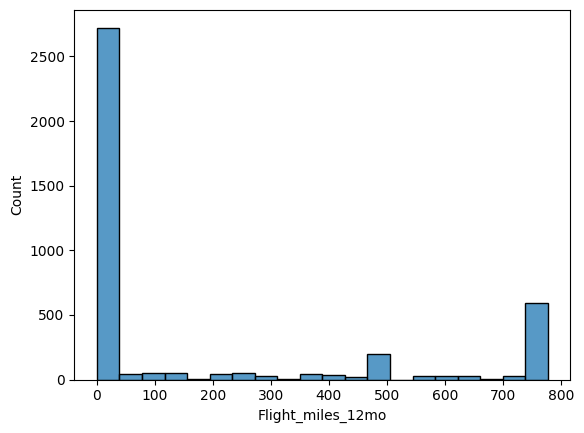

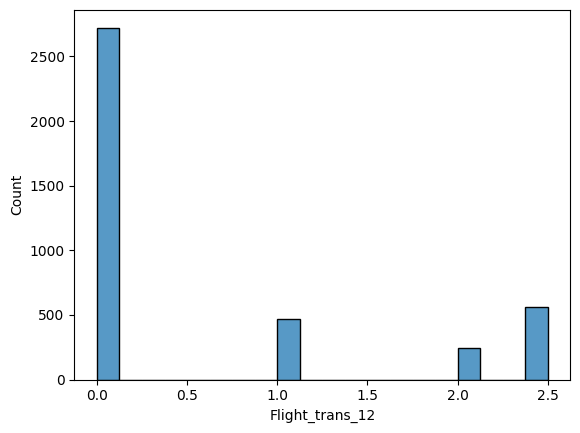

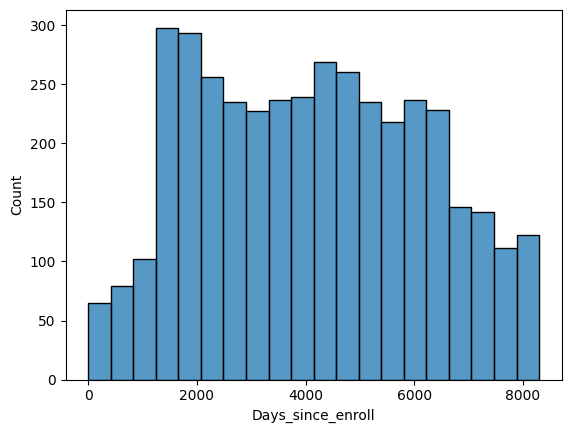

In [17]:
for col in df.columns:
  if col != 'ID#' and col != 'Award?':
     sns.histplot(df[col])
     plt.show()


From the plot we can interpret that
- Balance - Right skeweness, positive extreme values
- Qual_miles - Unimodal, the data is distributed in the center
- cc1_miles - Right skeweness, positive extreme values
- cc2_miles - Unimodal , the data is distributed in between 0.6 and 1.4 equally
- cc3_miles - Unimodal , the data is distributed in between 0.6 and 1.4 equally
- Bonus_miles - Right skeweness, positive extreme values
- Bonus_trans - Right skeweness, positive extreme values
- Flight_miles_12mo - Right skeweness, positive extreme values
- Flight_trans_12 - Right skeweness, positive extreme values
- Days_since_enroll - Roughly Right skeweness, positive extreme values

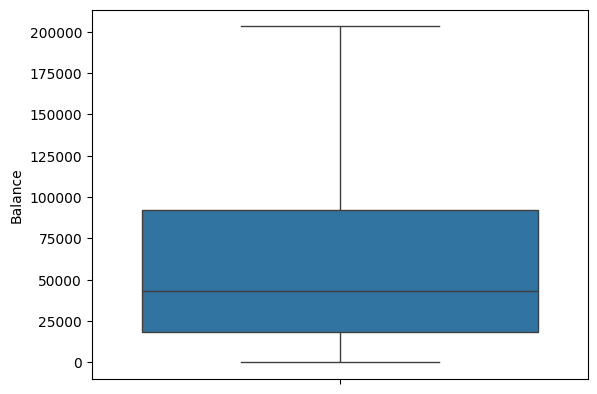

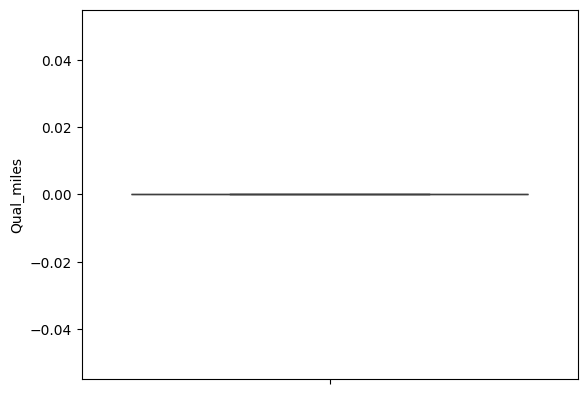

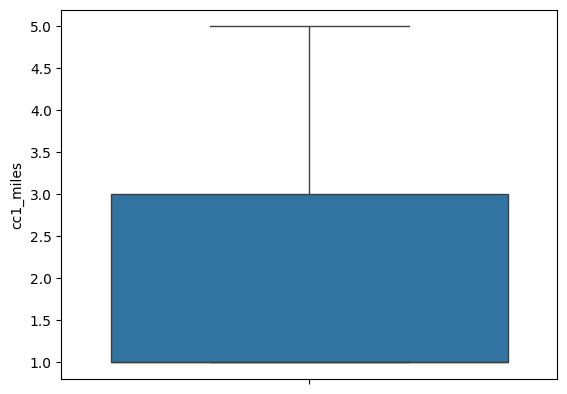

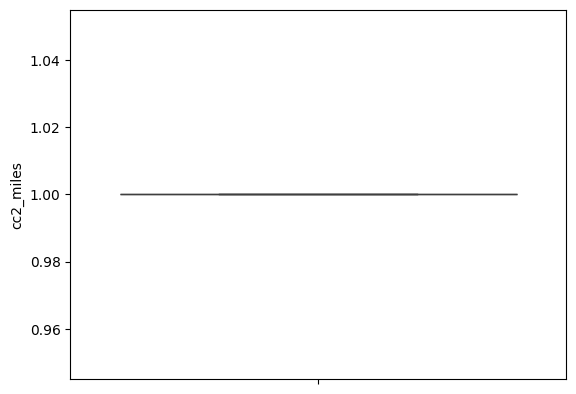

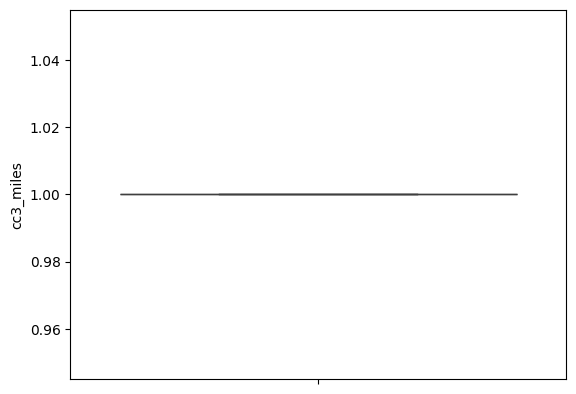

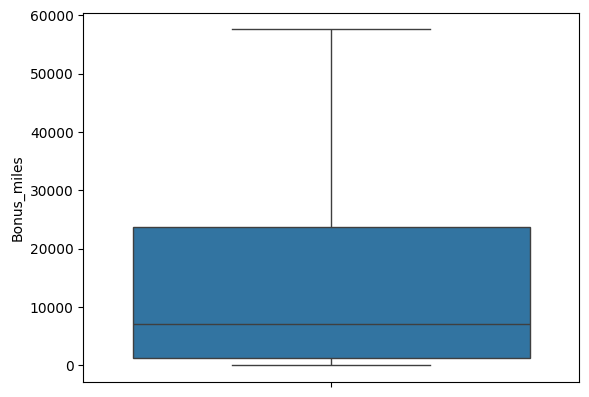

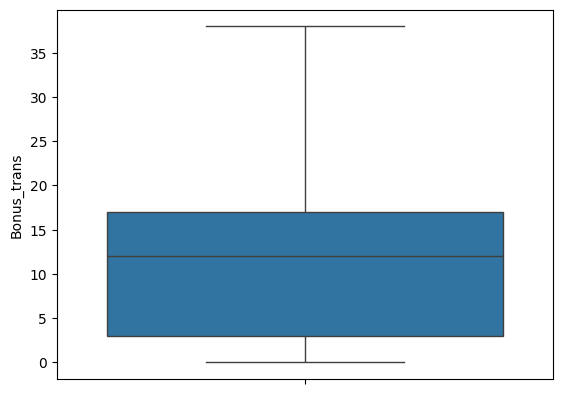

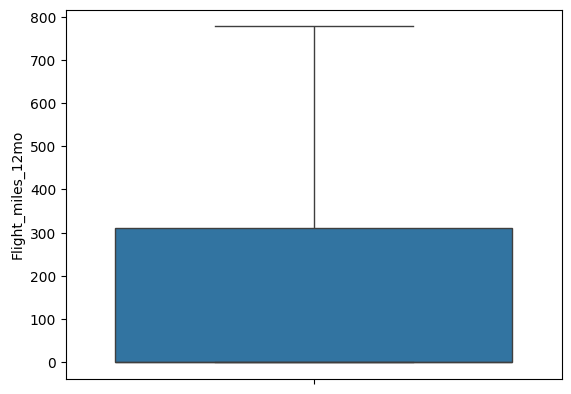

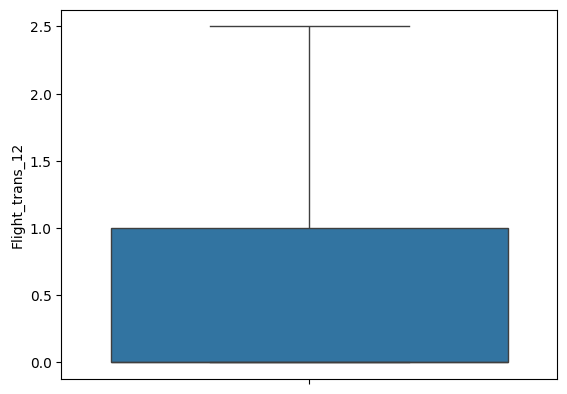

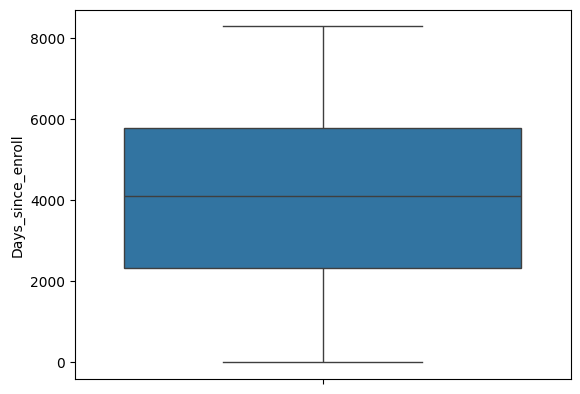

In [18]:
for col in df.columns:
  if col != 'ID#' and col !='Award?':
    sns.boxplot(df[col])
    plt.show()

There is no outliers detect in the boxplot, because i already applied outlier capping.

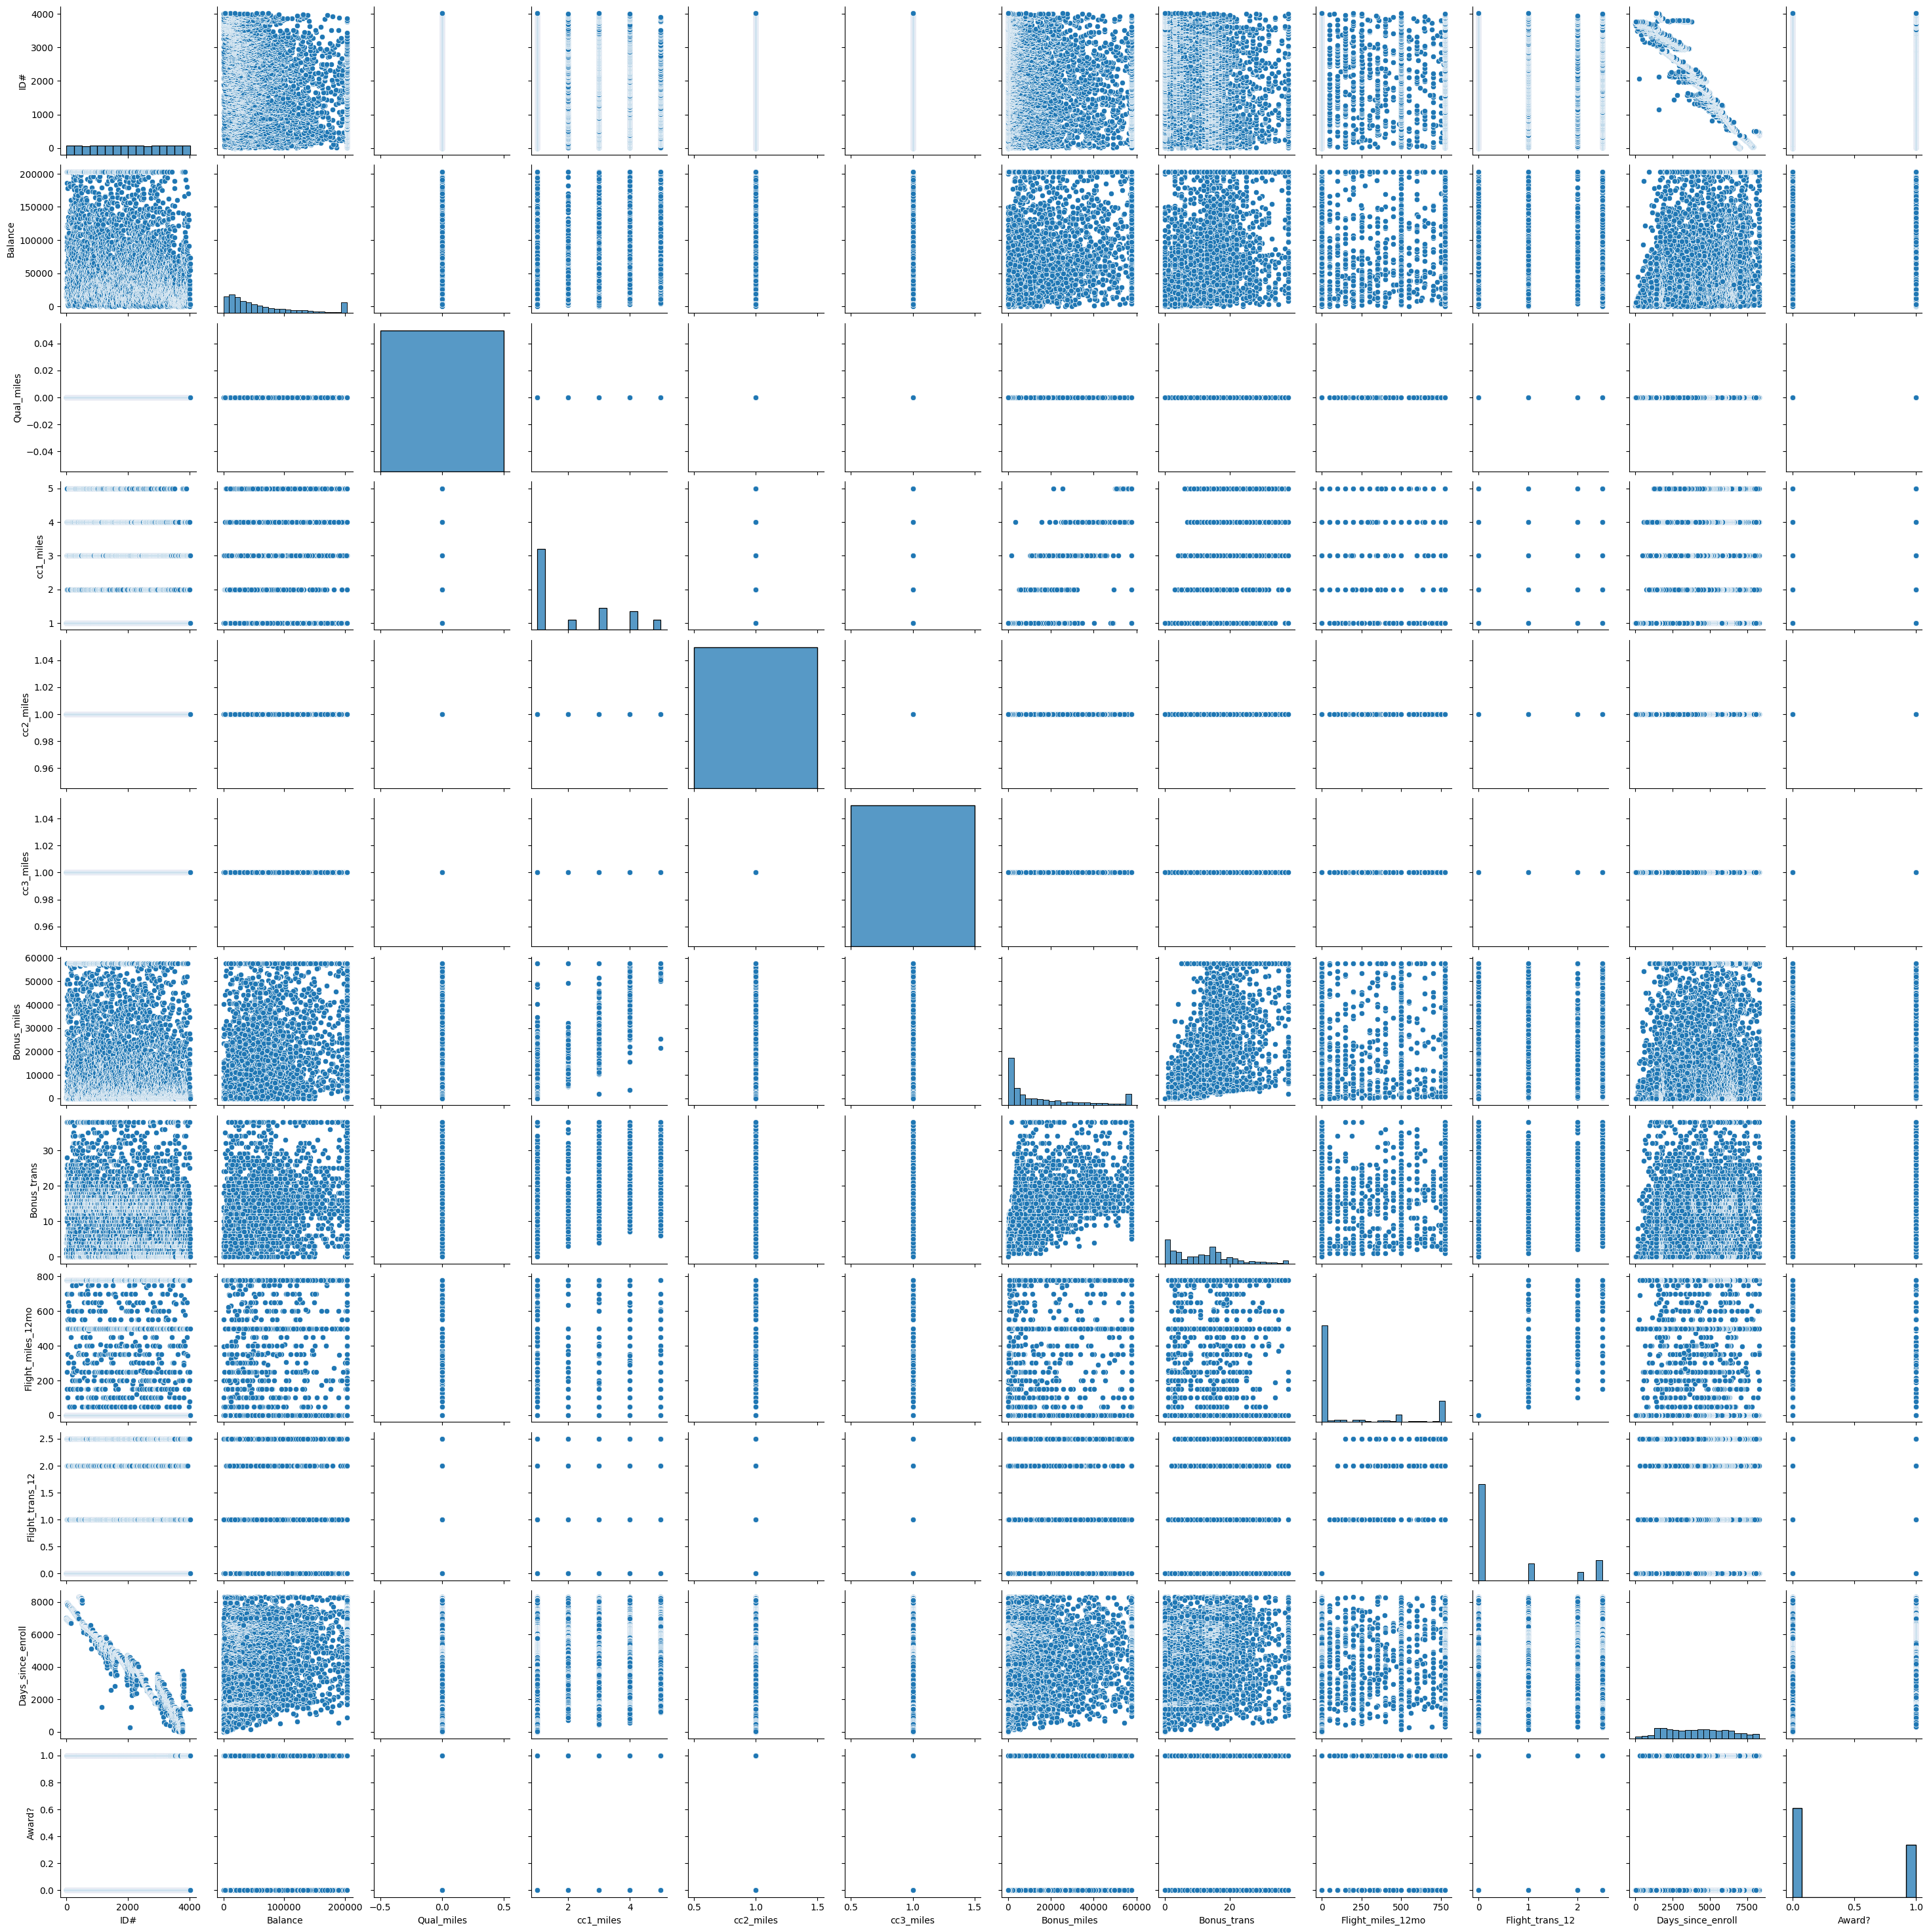

In [19]:
sns.pairplot(df)

<Axes: >

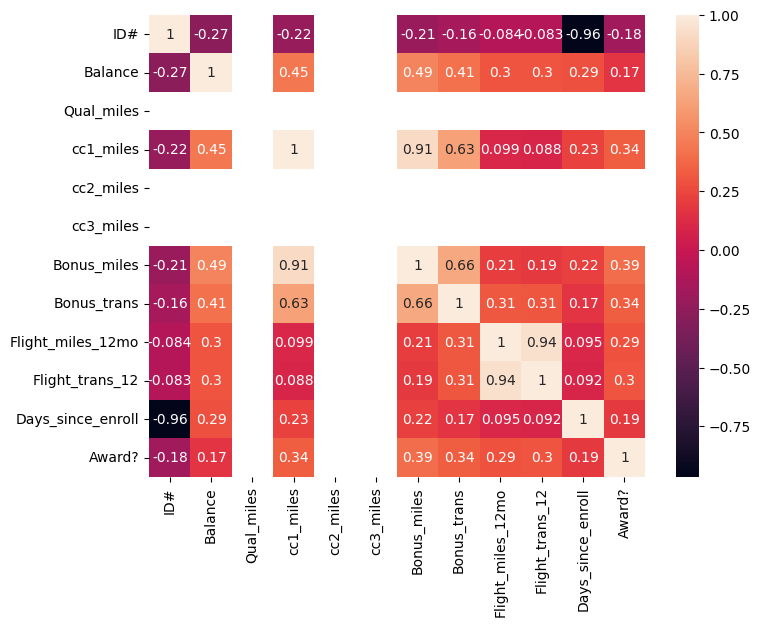

In [20]:
corr = df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True)

From the above heatmap we can see some of the columns are strongly correlated. The values are very high for some columns.
Strongly correlated columns :
- Bonus_miles and cc1_miles
- Bonus_trans and cc1_miles
- Bonus_trans and Bonus_miles
- Flight_trans_12 and Flight_miles_12mo

In [21]:
## KMeans algorithm

In [22]:
from sklearn.cluster import KMeans

In [23]:
df1.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
0,-0.607258,0.0,-0.769578,0.0,0.0,-0.843091,-1.148854,-0.604313,-0.626143,1.395454
1,-0.758947,0.0,-0.769578,0.0,0.0,-0.840822,-1.039133,-0.604313,-0.626143,1.379957
2,-0.382070,0.0,-0.769578,0.0,0.0,-0.624581,-0.819689,-0.604313,-0.626143,1.411920
3,-0.835106,0.0,-0.769578,0.0,0.0,-0.825052,-1.148854,-0.604313,-0.626143,1.372208
4,0.579265,0.0,1.409471,0.0,0.0,1.543191,1.594189,2.034489,2.020176,1.363975


In [24]:
kmeans = KMeans(n_clusters=3,random_state=100)
kmeans.fit(df1)

KMeans(n_clusters=3, random_state=100)

In [25]:
clusters = kmeans.labels_
clusters

array([1, 1, 1, ..., 0, 1, 1], dtype=int32)

In [26]:
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=100)
    kmeans.fit(df1)
    inertia.append(kmeans.inertia_)
print(inertia)

[27992.99999999999, 18910.863939963092, 14315.866312716196, 11943.073185909621, 10451.121901944209, 9415.501212125924, 8807.861763630293, 8365.244424098215, 7704.462330468225, 7308.413761546361]


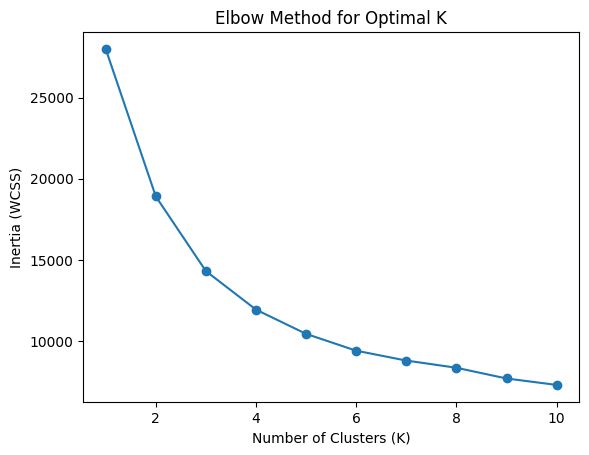

In [27]:
plt.plot(K, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal K')
plt.show()

- At K = 1 → high inertia (bad clustering)
- As K increases inertia decreases. After some K improvement becomes small
- That slow down point 4 is the optimal K

- Inertia (WCSS) = distance of points from their cluster center
- As K increases:
Inertia decreases
- But after some point:
Improvement slows down forms an elbow

In [28]:
## i use optimal value 4
kmeans1 = KMeans(n_clusters=4,random_state=100)
kmeans1.fit(df1)
labels = kmeans1.predict(df1)
df1['Cluster'] = labels

In [29]:
from sklearn.metrics import silhouette_score

In [30]:
score = silhouette_score(df1, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.39049054152137425


The silhoutte score is close to one that means good cluster

In [31]:
df1['Cluster'].value_counts()

,count
Cluster,
1,1927
0,1048
3,632
2,392


The clustering results show that the data is divided into four clusters with sizes 1600, 1107, 680, and 612. The clusters are moderately imbalanced, with one dominant cluster and smaller groups representing distinct customer segments. However, no cluster is too small, indicating stable clustering. This suggests that the dataset contains heterogeneous customer groups with varying behaviors

In [32]:
## DBSCAN algorithm

In [34]:
dbscan = DBSCAN(eps=0.5,min_samples=5)
labels1 = dbscan.fit_predict(df1)
df1['db_clusters'] = labels1

In [37]:
df1['db_clusters'].value_counts()

,count
db_clusters,
0,1489
-1,1412
2,312
5,186
1,148
3,144
21,41
23,38
10,21


In [48]:
## Experiment with different parameters
eps_values = [0.7, 0.9, 1.2, 1.5]
min_samples_values = [5, 10]
results = []
for eps in eps_values:
    for min_s in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels2 = db.fit_predict(df1)
        clusters2 = len(set(labels2)) - (1 if -1 in labels2 else 0)
        noise = list(labels2).count(-1)
        results.append([eps, min_s, clusters2, noise])




In [49]:
cluster_table = pd.DataFrame(results, columns=['Epsilon (eps)', 'Min Samples', 'No. of Clusters', 'Noise Points'])
print(cluster_table)

   Epsilon (eps)  Min Samples  No. of Clusters  Noise Points
0            0.7            5               71          1063
1            0.7           10               14          1543
2            0.9            5               57           503
3            0.9           10               34          1170
4            1.2            5               31           113
5            1.2           10               17           339
6            1.5            5               29            22
7            1.5           10               15           126


From the above table we can see that most of the cases either noise is high or cluster is high. But there is one case we can accept.
- eps = 1.5 and min samples = 10, in this case no of clusters is 15 and Noise points is 126. this is an optimal case.

from the above table we can see,

- Cluster 0 - 1489 points (largest cluster)
- -1 (it is the noise) - 1412 points (very high) , that means DBSCAN is unable to group many points because parameters not well tuned.
- There are too many small clusters , Model is over fragmenting the data by
creating too many small groups.
- Current DBSCAN parameters (eps, min_samples) are not optimal.

- The K-Means clustering algorithm produced four distinct clusters representing different customer segments such as low-value customers, moderate users, frequent flyers, and high-value loyal customers. These clusters were well-balanced and easy to interpret, making K-Means suitable for customer segmentation.
- DBSCAN generated multiple clusters along with some noise points, indicating the presence of outliers in the dataset. While DBSCAN was effective in identifying unusual data points and capturing complex structures, it resulted in a higher number of smaller clusters, making interpretation more challenging.
- Overall, K-Means provided clearer segmentation, whereas DBSCAN offered better insights into data density and outliers.

In [50]:
from sklearn.decomposition import PCA

In [51]:
## For visualizing data we have to reduce into 2D data
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(df1)

In [52]:
## KMeans Scatter plot

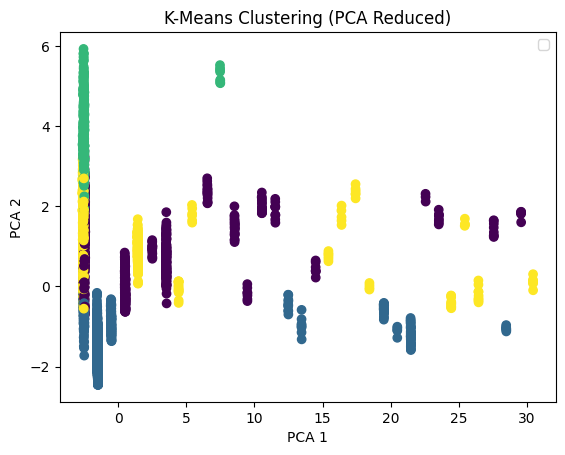

In [57]:
plt.scatter(reduced_data[:,0], reduced_data[:,1],
            c=df1['Cluster'], cmap='viridis')
plt.title("K-Means Clustering (PCA Reduced)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

The K-Means clustering visualization shows the formation of 4 clusters with a prominent dense vertical group on the left, representing customers with zero or very low activity. While K-Means successfully identifies this dense group, it struggles with separating overlapping regions, leading to some mixing of clusters, particularly among scattered data points.

In [58]:
## DBSCAN scatter plot

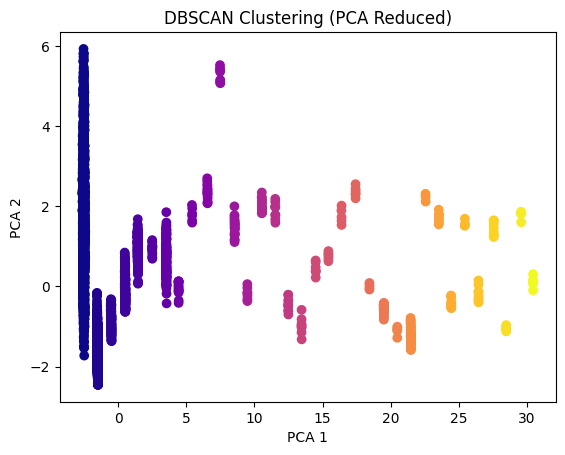

In [62]:
plt.scatter(reduced_data[:,0], reduced_data[:,1],
            c=df1['db_clusters'], cmap='plasma')
plt.title("DBSCAN Clustering (PCA Reduced)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

DBSCAN provides better separation of clusters by identifying groups based on density. It effectively captures the dense left-side cluster and clearly distinguishes multiple clusters on the right side of the plot. Unlike K-Means, DBSCAN handles irregular cluster shapes and varying densities more effectively, resulting in more meaningful segmentation.

In [63]:
## KMeans silhoutte score

In [65]:
kmeans_score = silhouette_score(df1, df1['Cluster'])
print("K-Means Silhouette Score:", kmeans_score)

K-Means Silhouette Score: 0.24632356675696354


In [66]:
## DBSCAN silhouette score

In [70]:
labels = df1['db_clusters']
mask = labels != -1
if len(set(labels[mask])) > 1:
    dbscan_score = silhouette_score(df1[mask], labels[mask])
    print("DBSCAN Silhouette Score:", dbscan_score)

DBSCAN Silhouette Score: 0.3785523995228681


- K-Means achieved a score of 0.246, indicating moderate cluster separation with some overlap between clusters. In contrast, DBSCAN achieved a higher silhouette score of 0.379, suggesting better-defined clusters with improved separation.
- However, DBSCAN produced a larger number of clusters, making interpretation more complex, whereas K-Means generated fewer and more interpretable clusters. Additionally, DBSCAN was effective in identifying noise points and handling irregular cluster shapes.
- Overall, DBSCAN demonstrated better clustering performance based on silhouette score, while K-Means provided simpler and more interpretable segmentation.